# Import Libraries

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from sklearn.linear_model import LinearRegression

# Load Dataset

In [9]:
df = pd.read_csv("C:\\Users\\ACER\\Documents\\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\\data\\Marvel_Cinematic_Universe_Dataset.csv")

df.head()

,title,type,release_year,mcu_phase_number,imdb_rating,rt_tomato_meter,rt_audience_score,production_budget,domestic_box_office,international_box_office,...,trailer_count,runtime (mins),genres,num votes,opening weekend,director,profit,roi,decade,success_category
0,iron man,Movie,2008,1,7.9,94,91,140000000,319034126.0,266762121.0,...,2,126,"Action, Adventure, Sci-Fi",1226243,102118668.0,Jon Favreau,445796247.0,318.425891,2000,Hit
1,the incredible hulk,Movie,2008,1,6.6,67,70,140000000,134806913.0,128620638.0,...,2,112,"Action, Sci-Fi",565286,55414050.0,Louis Leterrier,123427551.0,88.162536,2000,Hit
2,iron man 2,Movie,2010,1,6.9,72,71,200000000,312433331.0,311500000.0,...,2,124,"Action, Sci-Fi",939136,128122480.0,Jon Favreau,423933331.0,211.966666,2010,Hit
3,thor,Movie,2011,1,7.0,77,76,150000000,181030624.0,268295994.0,...,2,115,"Action, Fantasy",966962,65723338.0,Kenneth Brangh,299326618.0,199.551079,2010,Hit
4,captain america the first avenger,Movie,2011,1,6.9,79,75,140000000,176654505.0,193915269.0,...,2,124,"Action, Adventure, Sci-Fi",968488,65058524.0,Joe Johnston,230569774.0,164.692696,2010,Hit


# Check Missing Values

In [10]:
df.isnull().sum()

title                        0
type                         0
release_year                 0
mcu_phase_number             0
imdb_rating                  0
rt_tomato_meter              0
rt_audience_score            0
production_budget            0
domestic_box_office         13
international_box_office    13
worldwide_box_office        13
trailer_views                0
trailer_likes                0
trailer_count                0
runtime (mins)               0
genres                       0
num votes                    0
opening weekend             13
director                     0
profit                      13
roi                         13
decade                       0
success_category             0
dtype: int64

In [11]:
df.fillna(0, inplace=True)

,title,type,release_year,mcu_phase_number,imdb_rating,rt_tomato_meter,rt_audience_score,production_budget,domestic_box_office,international_box_office,...,trailer_count,runtime (mins),genres,num votes,opening weekend,director,profit,roi,decade,success_category
0,iron man,Movie,2008,1,7.9,94,91,140000000,319034126.0,2.667621e+08,...,2,126,"Action, Adventure, Sci-Fi",1226243,102118668.0,Jon Favreau,4.457962e+08,318.425891,2000,Hit
1,the incredible hulk,Movie,2008,1,6.6,67,70,140000000,134806913.0,1.286206e+08,...,2,112,"Action, Sci-Fi",565286,55414050.0,Louis Leterrier,1.234276e+08,88.162536,2000,Hit
2,iron man 2,Movie,2010,1,6.9,72,71,200000000,312433331.0,3.115000e+08,...,2,124,"Action, Sci-Fi",939136,128122480.0,Jon Favreau,4.239333e+08,211.966666,2010,Hit
3,thor,Movie,2011,1,7.0,77,76,150000000,181030624.0,2.682960e+08,...,2,115,"Action, Fantasy",966962,65723338.0,Kenneth Brangh,2.993266e+08,199.551079,2010,Hit
4,captain america the first avenger,Movie,2011,1,6.9,79,75,140000000,176654505.0,1.939153e+08,...,2,124,"Action, Adventure, Sci-Fi",968488,65058524.0,Joe Johnston,2.305698e+08,164.692696,2010,Hit
5,the avengers,Movie,2012,1,8.0,91,91,220000000,623357910.0,8.954420e+08,...,2,143,"Action, Sci-Fi",1559778,207438708.0,Joss Whedon,1.298800e+09,590.363595,2010,Blockbuster
6,iron man 3,Movie,2013,2,7.1,79,78,200000000,409013994.0,8.064260e+08,...,3,130,"Action, Adventure, Sci-Fi",967054,174144585.0,Shane Black,1.015440e+09,507.719997,2010,Blockbuster
7,thor the dark world,Movie,2013,2,6.8,66,75,170000000,206362140.0,4.384210e+08,...,2,112,"Animation, Action, Adventure, Fantasy, Sci-Fi",778590,85737841.0,Alan Taylor,4.747831e+08,279.284200,2010,Hit
8,captain america the winter soldier,Movie,2014,2,7.7,90,92,170000000,259766572.0,4.546549e+08,...,2,136,"Action, Adventure, Sci-Fi, Thriller",972967,95023721.0,Anthony and Joe Russo,5.444215e+08,320.247943,2010,Hit
9,guardians of the galaxy,Movie,2014,2,8.0,92,92,170000000,333176600.0,4.396978e+08,...,4,121,"Action, Adventure, Comedy, Sci-Fi",1365425,94320883.0,James Gunn,6.028744e+08,354.632000,2010,Hit


# Revenue Prediction Model

##### Features

In [13]:
X = df[
[
    "production_budget",
    "imdb_rating",
    "rt_audience_score",
    "rt_tomato_meter",
    "runtime (mins)",
    "mcu_phase_number",
    "num votes"
]
]

##### Target

In [14]:
y = df["worldwide_box_office"]

##### Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##### Linear Regression

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

##### Evaluate

In [40]:
print("Linear Regression")
print("R2 Score:", r2_score(y_test, pred_lr))

print("MAE:", mean_absolute_error(y_test, pred_lr))

Linear Regression
R2 Score: -9.593040474665672e+17
MAE: 617903934.008602


#### Random Forest Regressor

In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

##### Evaluate:

In [41]:
print("Random Forest")
print("R2 Score:", r2_score(y_test, pred_rf))

print("MAE:", mean_absolute_error(y_test, pred_rf))

Random Forest
R2 Score: -7.720941247357847e+17
MAE: 568145267.12


#### Feature Importance

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
6,num votes,0.396271
4,runtime (mins),0.252566
0,production_budget,0.152519
1,imdb_rating,0.128391
3,rt_tomato_meter,0.032464
2,rt_audience_score,0.025235
5,mcu_phase_number,0.012554


#### Visualization:

C:\Users\ACER\AppData\Local\Temp\ipykernel_33504\1435020220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ACER\AppData\Local\Temp\ipykernel_33504\1435020220.py:66: UserWarning: Glyph 129464 (\N{SUPERHERO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_33504\1435020220.py:68: UserWarning: Glyph 129464 (\N{SUPERHERO}) missing from font(s) DejaVu Sans.
  plt.savefig(
c:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129464 (\N{SUPERHERO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


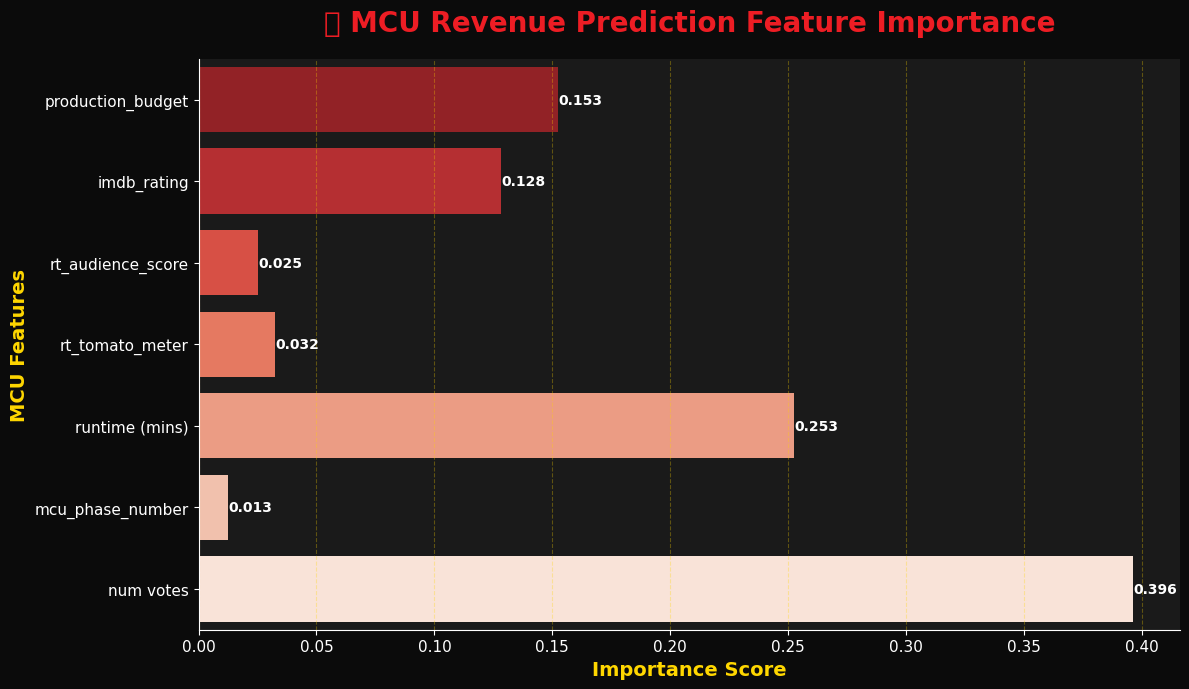

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Figure
plt.figure(figsize=(12, 7), facecolor="#0B0B0B")

# Dark Theme
ax = sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette="Reds_r"   # Marvel Red Gradient
)

# Background Colors
ax.set_facecolor("#1A1A1A")

# Title
plt.title(
    "🦸 MCU Revenue Prediction Feature Importance",
    fontsize=20,
    color="#ED1D24",   # Marvel Red
    fontweight="bold",
    pad=20
)

# Axis Labels
plt.xlabel(
    "Importance Score",
    fontsize=14,
    color="gold",
    fontweight="bold"
)

plt.ylabel(
    "MCU Features",
    fontsize=14,
    color="gold",
    fontweight="bold"
)

# Tick Colors
plt.xticks(color="white", fontsize=11)
plt.yticks(color="white", fontsize=11)

# Grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3,
    color='gold'
)

# Value Labels on Bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        color="white",
        fontweight="bold"
    )

# Remove Top/Right Borders
sns.despine(left=False, bottom=False)

plt.tight_layout()

plt.savefig(
    r"C:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\visuals\MCU_Revenue_Prediction_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Success Prediction Model

##### Target:

In [23]:
df.success_category

0             Hit
1             Hit
2             Hit
3             Hit
4             Hit
5     Blockbuster
6     Blockbuster
7             Hit
8             Hit
9             Hit
10    Blockbuster
11            Hit
12            Hit
13            Hit
14            Hit
15            Hit
16            Hit
17    Blockbuster
18    Blockbuster
19            Hit
20            Hit
21    Blockbuster
22            Hit
23            Hit
24           Flop
25            Hit
26            Hit
27            Hit
28            Hit
29            Hit
30            Hit
31    Blockbuster
32            Hit
33            Hit
34           Flop
35            Hit
36           Flop
37            Hit
38            Hit
39            Hit
40           Flop
41           Flop
42           Flop
43    Blockbuster
44            Hit
45           Flop
46            Hit
47           Flop
48           Flop
Name: success_category, dtype: str

##### Features

In [25]:
X = df[
[
    "production_budget",
    "imdb_rating",
    "rt_audience_score",
    "rt_tomato_meter",
    "runtime (mins)",
    "mcu_phase_number",
    "num votes"
]
]

##### Encode Target

In [26]:
le = LabelEncoder()

df["success_encoded"] = le.fit_transform(
    df["success_category"]
)

##### Target

In [27]:
y = df["success_encoded"]

##### Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##### Random Forest Classifier

In [29]:
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

##### Evaluate

In [30]:
print(
    accuracy_score(y_test, pred)
)

print(
    classification_report(
        y_test,
        pred
    )
)

0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2
           2       0.57      0.67      0.62         6

    accuracy                           0.50        10
   macro avg       0.30      0.39      0.34        10
weighted avg       0.41      0.50      0.45        10



c:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning

#### Confusion Matrix

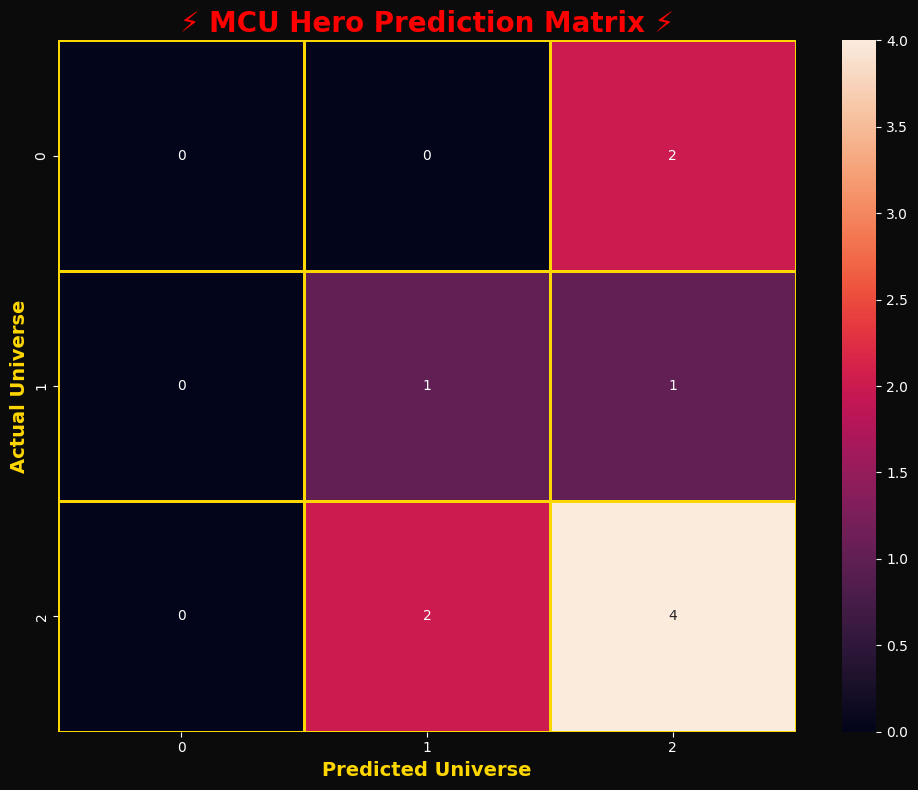

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# use the classifier's test predictions (pred_class) which match y_test's length
cm = confusion_matrix(y_test, pred_class)

plt.figure(figsize=(10,8), facecolor="#0B0B0B")

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='rocket',   # Marvel red shades
    linewidths=1,
    linecolor='gold'
)

plt.title(
    "⚡ MCU Hero Prediction Matrix ⚡",
    fontsize=20,
    color='red',
    fontweight='bold'
)

plt.xlabel(
    "Predicted Universe",
    color='gold',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    "Actual Universe",
    color='gold',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.savefig(
    r"C:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\visuals\MCU_Hero_Prediction_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Marvel Success Score

In [34]:
df["success_score"] = (
    df["imdb_rating"] * 10
    +
    df["rt_audience_score"]
    +
    df["roi"]
)

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[
[
    "imdb_scaled",
    "audience_scaled",
    "roi_scaled"
]
] = scaler.fit_transform(

    df[
    [
        "imdb_rating",
        "rt_audience_score",
        "roi"
    ]
    ]
)

create score:

In [38]:
df["success_score"] = (

    df["imdb_scaled"] * 0.4

    +

    df["audience_scaled"] * 0.3

    +

    df["roi_scaled"] * 0.3

) * 100

Check Top Movies

In [39]:
df[
[
    "title",
    "success_score"
]
].sort_values(
    by="success_score",
    ascending=False
).head(10)

,title,success_score
31,spider-man no way home,97.948718
21,avengers endgame,90.427821
18,avengers infinity war,87.385391
5,the avengers,83.539795
22,spider-man far from home,79.780043
43,deadpool&wolverine,79.050698
9,guardians of the galaxy,75.999694
16,thor ragnarok,73.373573
0,iron man,73.291607
12,captain america civil war,72.811805


#### Save Revenue Prediction Model

In [44]:
import joblib

joblib.dump(
    rf,
    "../models/revenue_prediction_model.pkl"
)

['../models/revenue_prediction_model.pkl']

#### Save Success Classification Model

In [45]:
joblib.dump(
    clf,
    "../models/success_classifier_model.pkl"
)

['../models/success_classifier_model.pkl']

Load Model

In [46]:
revenue_model = joblib.load(
    "../models/revenue_prediction_model.pkl"
)

classifier_model = joblib.load(
    "../models/success_classifier_model.pkl"
)

Save Label encoder

In [48]:
joblib.dump(
    le,
    "../models/label_encoder.pkl"
)

['../models/label_encoder.pkl']


Load:

In [49]:
le = joblib.load(
    "../models/label_encoder.pkl"
)

##### Convert prediction back:

In [50]:
pred_class = clf.predict(X_test)

le.inverse_transform(pred_class)

array(['Hit', 'Hit', 'Flop', 'Flop', 'Hit', 'Flop', 'Hit', 'Hit', 'Hit',
       'Hit'], dtype=object)

#### Save Success Score Dataset

In [51]:
df.to_csv(
    "../data/final_marvel_dataset.csv",
    index=False
)

#### Model Comparison Table

In [54]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest Regressor",
        "Random Forest Classifier"
    ],

    "Metric":[
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        accuracy_score(y_test, pred)
    ]
})

results

,Model,Metric
0,Linear Regression,-9.593040e+17
1,Random Forest Regressor,-7.720941e+17
2,Random Forest Classifier,5.000000e-01


##### Save:

In [56]:
results.to_csv(
    "../results/model_performance.csv",
    index=False
)

#### Test Saved Model

#### Revenue Model

In [57]:
import joblib

model = joblib.load(
    "../models/revenue_prediction_model.pkl"
)

##### Sample Movie

In [58]:
sample = [[
    200000000,
    8.2,
    90,
    92,
    150,
    5,
    1000000
]]

##### Predict:

In [59]:
prediction = model.predict(sample)

print(prediction)

[1.23615029e+09]


c:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


#### Test Success Classifier

In [60]:
clf = joblib.load(
    "../models/success_classifier_model.pkl"
)

le = joblib.load(
    "../models/label_encoder.pkl"
)

##### Predict:

In [61]:
pred = clf.predict(sample)

print(
    le.inverse_transform(pred)
)

['Hit']


c:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [73]:
df["phase_name"] = (
    "Phase " +
    df["mcu_phase_number"].astype(str)
)

In [74]:
df.to_csv(
    "Marvel_MCU_Final_Analytics_Dataset.csv",
    index=False
)


In [75]:
# Revenue in Millions
df["revenue_millions"] = (
    df["worldwide_box_office"] / 1000000
)

# Budget in Millions
df["budget_millions"] = (
    df["production_budget"] / 1000000
)

In [76]:
df.to_csv(
    "Marvel_MCU_Final_Analytics_Dataset_BI.csv",
    index=False
)

In [78]:
def get_franchise(title):

    if "iron man" in title.lower():
        return "Iron Man"

    elif "thor" in title.lower():
        return "Thor"

    elif "captain america" in title.lower():
        return "Captain America"

    elif "spider-man" in title.lower():
        return "Spider-Man"

    elif "guardians" in title.lower():
        return "Guardians"

    elif "avengers" in title.lower():
        return "Avengers"

    else:
        return "Other"

In [79]:
df["franchise"] = df["title"].apply(
    get_franchise
)

In [80]:
df.head(30)

,title,type,release_year,mcu_phase_number,imdb_rating,rt_tomato_meter,rt_audience_score,production_budget,domestic_box_office,international_box_office,...,success_category,success_encoded,success_score,imdb_scaled,audience_scaled,roi_scaled,phase_name,revenue_millions,budget_millions,franchise
0,iron man,Movie,2008,1,7.9,94,91,140000000,319034126.0,2.667621e+08,...,Hit,2,73.291607,0.871795,0.893939,0.386721,Phase 1,585.796247,140.0,Iron Man
1,the incredible hulk,Movie,2008,1,6.6,67,70,140000000,134806913.0,1.286206e+08,...,Hit,2,42.603623,0.538462,0.575758,0.126414,Phase 1,263.427551,140.0,Other
2,iron man 2,Movie,2010,1,6.9,72,71,200000000,312433331.0,3.115000e+08,...,Hit,2,50.333809,0.615385,0.590909,0.266372,Phase 1,623.933331,200.0,Iron Man
3,thor,Movie,2011,1,7.0,77,76,150000000,181030624.0,2.682960e+08,...,Hit,2,53.211113,0.641026,0.666667,0.252336,Phase 1,449.326618,150.0,Thor
4,captain america the first avenger,Movie,2011,1,6.9,79,75,140000000,176654505.0,1.939153e+08,...,Hit,2,50.548732,0.615385,0.651515,0.212930,Phase 1,370.569774,140.0,Captain America
5,the avengers,Movie,2012,1,8.0,91,91,220000000,623357910.0,8.954420e+08,...,Blockbuster,0,83.539795,0.897436,0.893939,0.694139,Phase 1,1518.799910,220.0,Avengers
6,iron man 3,Movie,2013,2,7.1,79,78,200000000,409013994.0,8.064260e+08,...,Blockbuster,0,65.597144,0.666667,0.696970,0.600713,Phase 2,1215.439994,200.0,Iron Man
7,thor the dark world,Movie,2013,2,6.8,66,75,170000000,206362140.0,4.384210e+08,...,Hit,2,53.409369,0.589744,0.651515,0.342472,Phase 2,644.783140,170.0,Thor
8,captain america the winter soldier,Movie,2014,2,7.7,90,92,170000000,259766572.0,4.546549e+08,...,Hit,2,71.756664,0.820513,0.909091,0.388781,Phase 2,714.421503,170.0,Captain America
9,guardians of the galaxy,Movie,2014,2,8.0,92,92,170000000,333176600.0,4.396978e+08,...,Hit,2,75.999694,0.897436,0.909091,0.427651,Phase 2,772.874400,170.0,Guardians


In [84]:
franchise_health = df.groupby(
    "franchise"
).agg({

    "success_score":"mean",

    "imdb_rating":"mean",

    "worldwide_box_office":"mean"

})

In [85]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

franchise_health[
    "revenue_scaled"
] = scaler.fit_transform(

    franchise_health[
        ["worldwide_box_office"]
    ]

)

In [87]:
franchise_health["health_score"] = (

    franchise_health["success_score"]*0.4

    +

    franchise_health["imdb_rating"]*10*0.3

    +

    franchise_health["revenue_scaled"]*100*0.3

)
print(franchise_health)

                 success_score  imdb_rating  worldwide_box_office  \
franchise                                                           
Avengers             82.423412     8.025000          1.941938e+09   
Captain America      58.193372     7.050000          6.633517e+08   
Guardians            72.262539     7.833333          8.273954e+08   
Iron Man             63.074187     7.300000          8.083899e+08   
Other                50.426300     6.789286          3.567894e+08   
Spider-Man           82.314874     7.666667          1.311324e+09   
Thor                 56.290878     6.975000          6.772638e+08   

                 revenue_scaled  health_score  
franchise                                      
Avengers               1.000000     87.044365  
Captain America        0.193397     50.229246  
Guardians              0.296884     61.311550  
Iron Man               0.284895     55.676516  
Other                  0.000000     40.538377  
Spider-Man             0.602174     73.991

In [88]:
director_df = df.groupby("director").agg({

    "worldwide_box_office":"sum",

    "roi":"mean",

    "imdb_rating":"mean",

    "title":"count"

}).reset_index()

In [89]:
director_df.columns = [

    "director",

    "total_revenue",

    "avg_roi",

    "avg_imdb",

    "movie_count"

]

In [90]:
director_df.to_csv(
    "director_analytics.csv",
    index=False
)
